<a href="https://colab.research.google.com/github/TramSt/du-doan-gia-nha-dat-hcm/blob/main/notebooks/03_eda_truc_quan_hoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân tích khám phá dữ liệu (EDA) — Dự đoán giá bất động sản TP.HCM

**Bài tập 3 — Nhóm 7-8**

Dữ liệu: `data/processed/df_clean.csv` (7.436 tin đăng, đã chuẩn hóa từ CafeLand và Batdongsan.vn)

Notebook này thực hiện:
1. Tổng quan dữ liệu (cấu trúc, kiểu biến, giá trị thiếu)
2. Thống kê mô tả cho biến số và biến hạng
3. ≥8 biểu đồ trực quan chuyên nghiệp
4. Nhận xét sau mỗi biểu đồ và kết luận tổng hợp cho bước chọn mô hình


In [ ]:
pip install numpy pandas matplotlib

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
%matplotlib inline

In [ ]:
# ==========================================================
# Cấu hình giao diện biểu đồ — palette CVD-safe (đã kiểm định)
# ==========================================================

COLORS = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CAT_ORDER = ["blue", "orange", "aqua", "yellow", "magenta", "green", "violet", "red"]
CAT_PALETTE = [COLORS[c] for c in CAT_ORDER]

SURFACE, INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK_PRIMARY, "axes.labelcolor": INK_SECONDARY, "axes.edgecolor": BASELINE,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "font.family": "sans-serif", "font.size": 10.5,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK_PRIMARY,
    "axes.spines.top": False, "axes.spines.right": False,
})

def dinh_dang_gia(x, pos):
    return f"{x/1000:,.0f} tỷ" if x >= 1000 else f"{x:,.0f} tr"

FMT_GIA = mticker.FuncFormatter(dinh_dang_gia)

## 1. Tải và tổng quan dữ liệu

In [ ]:
URL_DU_LIEU = (
    "https://raw.githubusercontent.com/TramSt/du-doan-gia-nha-dat-hcm/"
    "main/data/processed/df_clean.csv"
)
df = pd.read_csv(URL_DU_LIEU)

In [ ]:
df = pd.read_csv("../data/processed/df_clean.csv")
print(f"Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/df_clean.csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7436 entries, 0 to 7435
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gia_ban          7436 non-null   float64
 1   log_gia_ban      7436 non-null   float64
 2   dien_tich_m2     7436 non-null   float64
 3   log_dien_tich    7436 non-null   float64
 4   quan_huyen       7436 non-null   object 
 5   phuong           7436 non-null   object 
 6   ten_duong        7436 non-null   object 
 7   loai_hinh        7436 non-null   object 
 8   so_phong_ngu     7436 non-null   float64
 9   so_tang          7436 non-null   float64
 10  so_wc            7436 non-null   float64
 11  mat_tien_m       7436 non-null   float64
 12  rong_hem_m       7436 non-null   float64
 13  mat_do_xay       7436 non-null   float64
 14  la_hem           7436 non-null   int64  
 15  la_mat_tien      7436 non-null   int64  
 16  co_so_hong       7436 non-null   int64  
 17  co_noi_that   

In [ ]:
print("Giá trị thiếu theo cột:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Không có giá trị thiếu — dữ liệu đã được làm sạch đầy đủ.")

Giá trị thiếu theo cột:
Không có giá trị thiếu — dữ liệu đã được làm sạch đầy đủ.


**Nhận xét:** Dữ liệu không có giá trị thiếu ở bất kỳ cột nào — bước làm sạch trước đó (`lam_sach_du_lieu.py`) đã xử lý triệt để. Có 27 cột gồm biến số (giá, diện tích, số phòng...), biến hạng (quận/huyện, loại hình...), và biến nhị phân (là hẻm, có sổ hồng...).

## 2. Thống kê mô tả

In [ ]:
bien_so = ["gia_ban", "dien_tich_m2", "so_phong_ngu", "so_tang", "so_wc", "mat_do_xay"]
df[bien_so].describe().round(1)

,gia_ban,dien_tich_m2,so_phong_ngu,so_tang,so_wc,mat_do_xay
count,7436.0,7436.0,7436.0,7436.0,7436.0,7436.0
mean,9970.8,84.8,3.5,2.6,3.2,216.4
std,7413.2,46.6,1.6,1.6,1.2,197.5
min,340.0,15.0,1.0,1.0,1.0,15.0
25%,5000.0,53.3,3.0,1.0,2.0,87.0
50%,7500.0,72.0,3.0,2.0,3.0,159.0
75%,12500.0,101.0,4.0,4.0,4.0,280.0
max,44000.0,270.0,10.0,8.0,8.0,2080.0


In [ ]:
print("Cơ cấu loại hình BĐS:")
print(df["loai_hinh"].value_counts())
print()
print("Nguồn dữ liệu:")
print(df["nguon_du_lieu"].value_counts())
print()
print(f"Số quận/huyện: {df['quan_huyen'].nunique()}")

Cơ cấu loại hình BĐS:
loai_hinh
Nhà riêng       3580
Nhà phố          970
Căn hộ           949
Nhà mặt tiền     801
Đất              680
Biệt thự         425
Shophouse         24
Khác               7
Name: count, dtype: int64

Nguồn dữ liệu:
nguon_du_lieu
batdongsan    4400
cafeland      3036
Name: count, dtype: int64

Số quận/huyện: 20


**Nhận xét:** Giá bán trung vị khoảng 7.500 triệu nhưng trung bình 9.970,8 triệu chênh nhau ~33%, tín hiệu lệch phải sẽ kiểm chứng ở mục 3.1. `mat_do_xay` cũng lệch mạnh với trung vị 159, max 2.080 sẽ chứng minh ở phần 3.7 rằng biến này không chỉ là rủi ro ngoại lai mà còn là ứng viên dự báo giá đáng chú ý. `Nhà riêng` chiếm 48,1% với 3.580/7.436; Shophouse (24 tin) và `Khác` (7 tin) dưới ngưỡng đáng tin cậy, sẽ loại khỏi các so sánh theo nhóm ở phần sau.

## 3. Trực quan hóa dữ liệu

### 3.1. Phân phối giá bán (gốc vs. log)

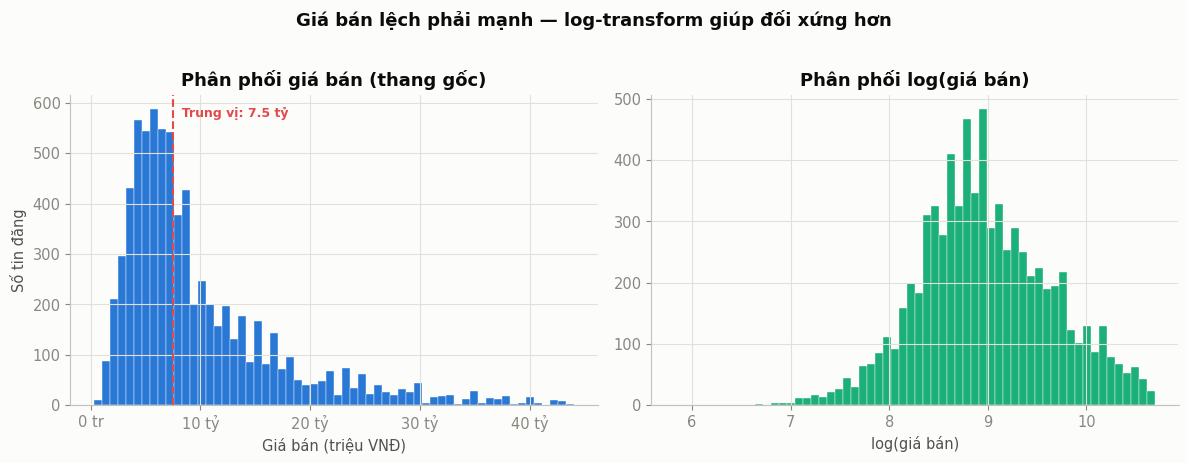

Độ lệch (skewness) giá gốc : 1.76
Độ lệch (skewness) log(giá): 0.09


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["gia_ban"], bins=60, color=COLORS["blue"], edgecolor=SURFACE, linewidth=0.3)
axes[0].set_title("Phân phối giá bán (thang gốc)")
axes[0].set_xlabel("Giá bán (triệu VNĐ)")
axes[0].set_ylabel("Số tin đăng")
axes[0].xaxis.set_major_formatter(FMT_GIA)
axes[0].axvline(df["gia_ban"].median(), color=COLORS["red"], linewidth=1.5, linestyle="--")
axes[0].text(df["gia_ban"].median(), axes[0].get_ylim()[1]*0.93,
             f"  Trung vị: {df['gia_ban'].median()/1000:.1f} tỷ",
             color=COLORS["red"], fontsize=9, fontweight="bold")

axes[1].hist(df["log_gia_ban"], bins=60, color=COLORS["aqua"], edgecolor=SURFACE, linewidth=0.3)
axes[1].set_title("Phân phối log(giá bán)")
axes[1].set_xlabel("log(giá bán)")

fig.suptitle("Giá bán lệch phải mạnh — log-transform giúp đối xứng hơn",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Độ lệch (skewness) giá gốc : {df['gia_ban'].skew():.2f}")
print(f"Độ lệch (skewness) log(giá): {df['log_gia_ban'].skew():.2f}")

**Nhận xét:** Giá bán lệch phải rất mạnh — một số ít bất động sản giá rất cao (biệt thự, nhà mặt tiền lớn) kéo trung bình lên xa trung vị. Skewness giảm từ 1,76 xuống 0,09 sau log-transform phân phối gần đối xứng hơn nhiều. Điều này xác nhận quyết định dùng `log_gia_ban` làm biến mục tiêu cho hồi quy tuyến tính là hợp lý, vì mô hình này giả định phần dư phân phối chuẩn. Quyết định xử lý ngoại lai: giữ nguyên các giá trị cao (max 44 tỷ, gấp 3,5 lần Q3) vì sau log-transform chúng không còn là điểm cực đoan tách biệt, nhiều khả năng là phân khúc cao cấp thật chứ không phải lỗi.

### 3.2. Phân phối diện tích

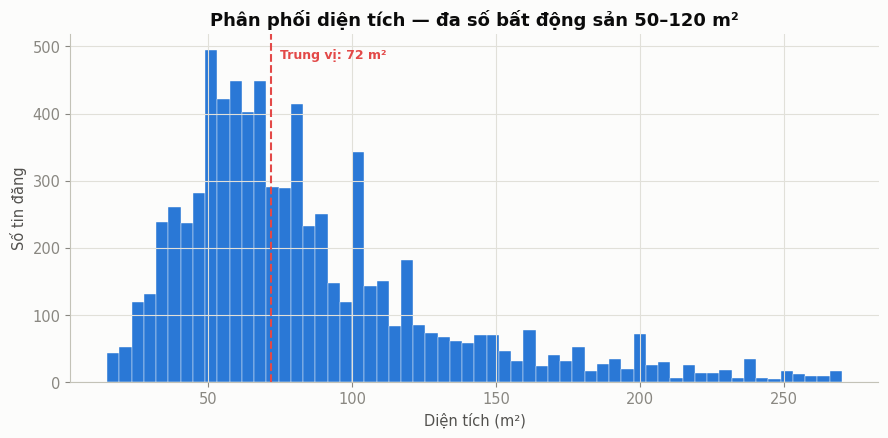

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df["dien_tich_m2"], bins=60, color=COLORS["blue"], edgecolor=SURFACE, linewidth=0.3)
ax.axvline(df["dien_tich_m2"].median(), color=COLORS["red"], linewidth=1.5, linestyle="--")
ax.text(df["dien_tich_m2"].median()+3, ax.get_ylim()[1]*0.93,
        f"Trung vị: {df['dien_tich_m2'].median():.0f} m²",
        color=COLORS["red"], fontsize=9, fontweight="bold")
ax.set_title("Phân phối diện tích — đa số bất động sản 50–120 m²")
ax.set_xlabel("Diện tích (m²)")
ax.set_ylabel("Số tin đăng")
fig.tight_layout()
plt.show()

**Nhận xét:** Diện tích trung vị 72 m² với IQR 53,3–101 m². Đuôi phải tới 270 m² (gấp 3,75 lần trung vị), cùng chiều lệch với giá bán. Diện tích tối thiểu 15 m² cần đối chiếu chéo với `loai_hinh` trước khi mô hình hóa — nếu gắn với nhãn "Biệt thự".

### 3.3. Quan hệ diện tích và giá bán

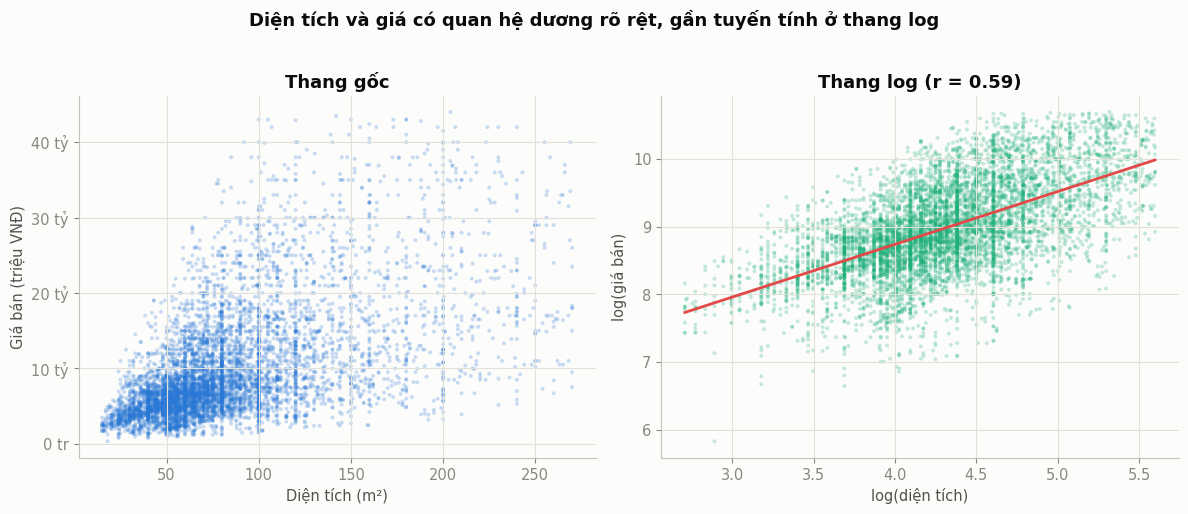

Tương quan Pearson (thang gốc) : 0.57
Tương quan Pearson (thang log) : 0.59


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["dien_tich_m2"], df["gia_ban"], s=8, alpha=0.25, color=COLORS["blue"], edgecolors="none")
axes[0].set_title("Thang gốc")
axes[0].set_xlabel("Diện tích (m²)")
axes[0].set_ylabel("Giá bán (triệu VNĐ)")
axes[0].yaxis.set_major_formatter(FMT_GIA)

axes[1].scatter(df["log_dien_tich"], df["log_gia_ban"], s=8, alpha=0.25, color=COLORS["aqua"], edgecolors="none")
z = np.polyfit(df["log_dien_tich"], df["log_gia_ban"], 1)
xs = np.linspace(df["log_dien_tich"].min(), df["log_dien_tich"].max(), 100)
axes[1].plot(xs, np.polyval(z, xs), color=COLORS["red"], linewidth=2)
corr = df["log_dien_tich"].corr(df["log_gia_ban"])
axes[1].set_title(f"Thang log (r = {corr:.2f})")
axes[1].set_xlabel("log(diện tích)")
axes[1].set_ylabel("log(giá bán)")

fig.suptitle("Diện tích và giá có quan hệ dương rõ rệt, gần tuyến tính ở thang log",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print(f"Tương quan Pearson (thang gốc) : {df['dien_tich_m2'].corr(df['gia_ban']):.2f}")
print(f"Tương quan Pearson (thang log) : {corr:.2f}")

**Nhận xét:** r = 0,57 ở thang gốc, tăng nhẹ lên 0,59 ở thang log-transform cải thiện khiêm tốn, cho thấy lợi ích chính của log-transform là làm thẳng dạng quan hệ chứ không phải tăng vọt tương quan. Giá trị r=0,57 này khớp chính xác với ô [Giá bán, Diện tích] trong ma trận tương quan sẽ được phân tích ở phần 3.7, xác nhận tính nhất quán giữa hai cách tính. Một mình diện tích (R²≈0,35) chưa đủ đạt mục tiêu R²≥0,60 của dự án nên cần kết hợp thêm vị trí và loại hình.

### 3.4. Giá bán theo loại hình bất động sản

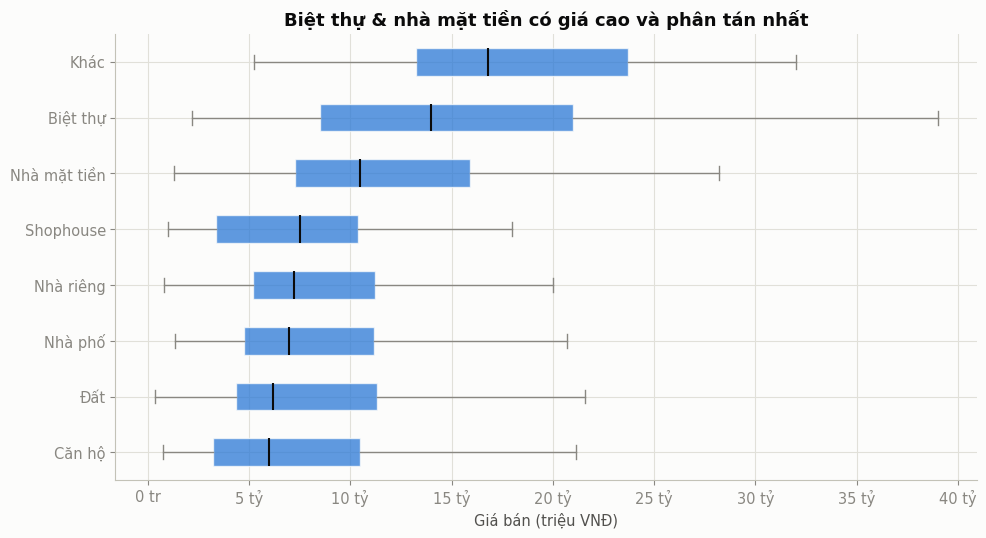

,gia_ban
loai_hinh,
Khác,16800.0
Biệt thự,14000.0
Nhà mặt tiền,10500.0
Shophouse,7500.0
Nhà riêng,7225.0
Nhà phố,6985.0
Đất,6200.0
Căn hộ,6000.0


In [ ]:
thu_tu_loai = df.groupby("loai_hinh")["gia_ban"].median().sort_values().index.tolist()
data_box = [df.loc[df["loai_hinh"] == lh, "gia_ban"].values for lh in thu_tu_loai]

fig, ax = plt.subplots(figsize=(10, 5.5))
bp = ax.boxplot(data_box, vert=False, patch_artist=True, showfliers=False,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5),
                 whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED))
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS["blue"]); patch.set_alpha(0.75); patch.set_edgecolor(SURFACE)
ax.set_yticklabels(thu_tu_loai)
ax.set_xlabel("Giá bán (triệu VNĐ)")
ax.xaxis.set_major_formatter(FMT_GIA)
ax.set_title("Biệt thự & nhà mặt tiền có giá cao và phân tán nhất")
fig.tight_layout()
plt.show()
df.groupby("loai_hinh")["gia_ban"].median().sort_values(ascending=False)

**Nhận xét:** Theo vị trí đường trung vị trên biểu đồ, nhóm giá thấp nhất là Căn hộ và Đất (~6 tỷ), nhóm giá cao nhất là "Khác" (~16-17 tỷ) và Biệt thự (~13-14 tỷ). Nhóm "Khác" chỉ có 7 tin, nên trung vị của nó gần như chắc chắn bị chi phối bởi 1-2 quan sát chứ không đại diện cho một phân khúc thật. Nếu chỉ so sánh các nhóm ≥30 tin, chênh lệch thực chất là Biệt thự/Căn hộ ≈ 2,2 lần. `loai_hinh` vẫn bắt buộc phải mã hóa (one-hot), nhưng cần lọc theo ngưỡng cỡ mẫu trước khi coi các mức là đáng tin.

### 3.5. Giá bán trung vị theo quận/huyện

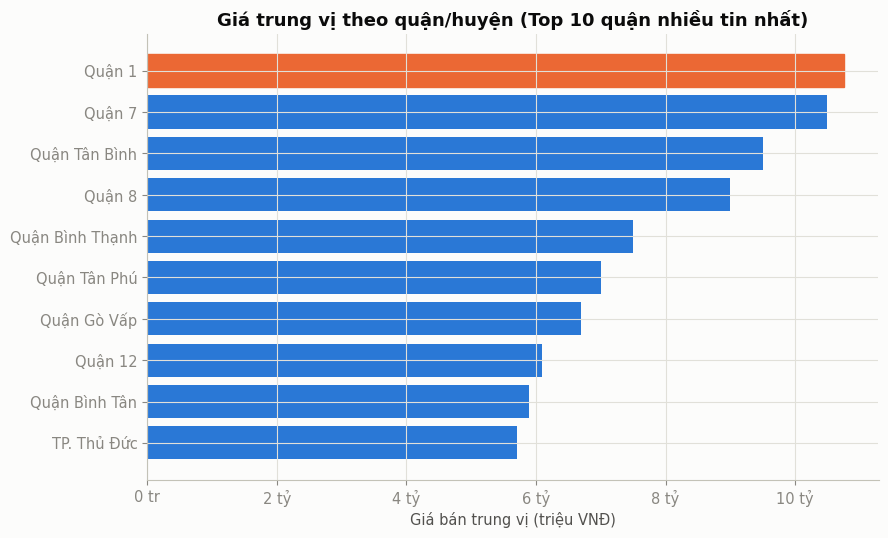

In [ ]:
top_quan = df["quan_huyen"].value_counts().head(10).index.tolist()
gia_theo_quan = (df[df["quan_huyen"].isin(top_quan)]
                  .groupby("quan_huyen")["gia_ban"].median().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(gia_theo_quan.index, gia_theo_quan.values, color=COLORS["blue"])
bars[-1].set_color(COLORS["orange"])
ax.xaxis.set_major_formatter(FMT_GIA)
ax.set_xlabel("Giá bán trung vị (triệu VNĐ)")
ax.set_title("Giá trung vị theo quận/huyện (Top 10 quận nhiều tin nhất)")
fig.tight_layout()
plt.show()

**Nhận xét:** Trong 10 quận nhiều tin nhất, Quận 1 có giá trung vị cao nhất với ~10,7 tỷ, gấp ~1,9 lần TP. Thủ Đức (~5,7 tỷ, thấp nhất trong nhóm này). Quận 7 (~10,4 tỷ) gần như ngang Quận 1, cao hơn hẳn các quận trung tâm truyền thống khác như Bình Thạnh hay Tân Bình, nhiều khả năng phản ánh hiệu ứng khu đô thị Phú Mỹ Hưng, cho thấy `vị trí` ảnh hưởng giá không chỉ theo ranh giới trung tâm/vùng ven mà còn theo các khu quy hoạch cao cấp cục bộ.

### 3.6. Số lượng tin đăng theo quận/huyện

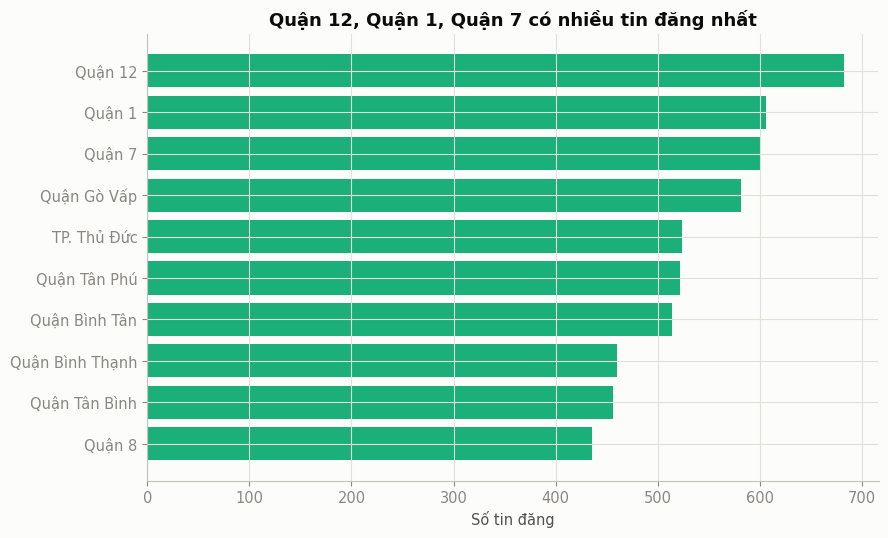

In [ ]:
so_luong_quan = df["quan_huyen"].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(so_luong_quan.index, so_luong_quan.values, color=COLORS["aqua"])
ax.set_xlabel("Số tin đăng")
ax.set_title("Quận 12, Quận 1, Quận 7 có nhiều tin đăng nhất")
fig.tight_layout()
plt.show()

**Nhận xét:** Ngay trong top 10 quận nhiều tin nhất, số lượng đã phân bố không đều với thấp nhất trong nhóm này là Quận 5 và Huyện Nhà Bè. 10 quận không lọt top 10 còn ít tin hơn nữa, nên cần đặt ngưỡng cỡ mẫu tối thiểu cho cả `quan_huyen` trước khi mã hóa(one-hot).

### 3.7. Ma trận tương quan giữa các biến số

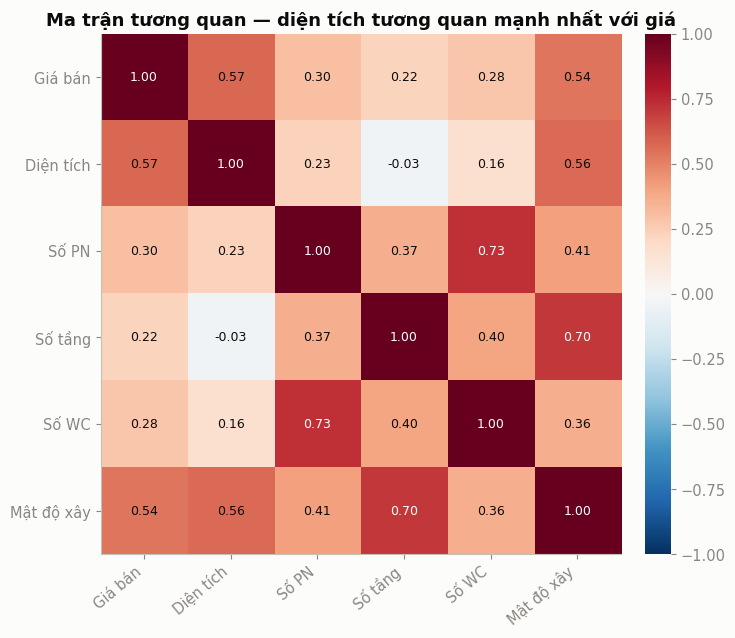

              gia_ban  dien_tich_m2  so_phong_ngu  so_tang  so_wc  mat_do_xay
gia_ban          1.00          0.57          0.30     0.22   0.28        0.54
dien_tich_m2     0.57          1.00          0.23    -0.03   0.16        0.56
so_phong_ngu     0.30          0.23          1.00     0.37   0.73        0.41
so_tang          0.22         -0.03          0.37     1.00   0.40        0.70
so_wc            0.28          0.16          0.73     0.40   1.00        0.36
mat_do_xay       0.54          0.56          0.41     0.70   0.36        1.00


In [ ]:
bien_so = ["gia_ban", "dien_tich_m2", "so_phong_ngu", "so_tang", "so_wc", "mat_do_xay"]
corr_matrix = df[bien_so].corr()
nhan = ["Giá bán", "Diện tích", "Số PN", "Số tầng", "Số WC", "Mật độ xây"]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(bien_so))); ax.set_yticks(range(len(bien_so)))
ax.set_xticklabels(nhan, rotation=40, ha="right"); ax.set_yticklabels(nhan)
ax.grid(False)

for i in range(len(bien_so)):
    for j in range(len(bien_so)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.6 else INK_PRIMARY
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.outline.set_visible(False)
ax.set_title("Ma trận tương quan — diện tích tương quan mạnh nhất với giá")
fig.tight_layout()
plt.show()
print(corr_matrix.round(2))

**Nhận xét:** Ma trận tương quan cho thấy diện tích (r=0,57) và mật độ xây (r=0,54) là hai biến tương quan mạnh nhất với giá bán — mật độ xây  gần ngang diện tích, một phát hiện đáng chú ý vì các phần trước chỉ xem `mat_do_xay` như rủi ro ngoại lai, chưa nhìn nó như một ứng viên đặc trưng dự báo giá thực thụ. Về đa cộng tuyến: số phòng ngủ và số WC có r=0,73 đang ở mức cao và số tầng với mật độ xây đạt r=0,70; cả hai cặp này cần cân nhắc chỉ giữ một biến đại diện hoặc dùng Ridge khi hồi quy tuyến tính. Diện tích và số tầng gần như không tương quan (r=-0,03), nhà đất rộng ở TP.HCM không có xu hướng xây cao tầng hơn, có thể phản ánh sự phân hóa giữa biệt thự/đất nền (rộng, thấp tầng) và nhà phố/nhà ống (hẹp, nhiều tầng)

### 3.8. Giá bán theo số phòng ngủ

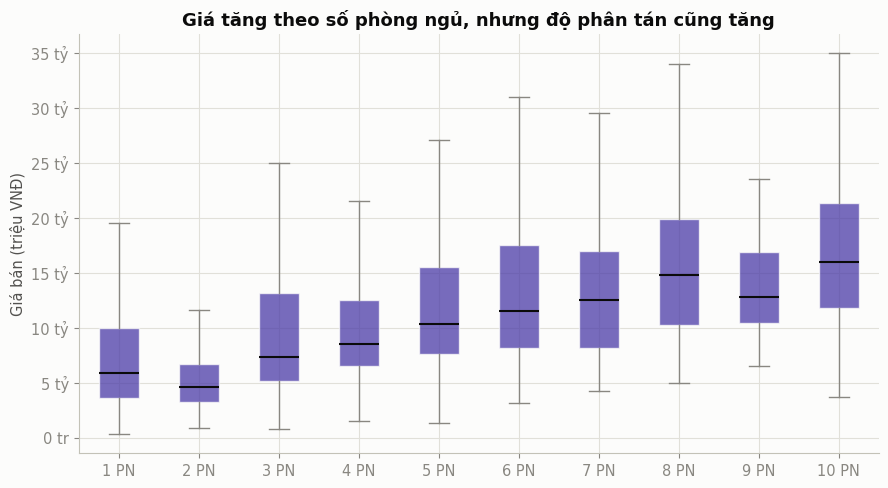

In [ ]:
pn_pho_bien = df["so_phong_ngu"].value_counts()
pn_giu = sorted(pn_pho_bien[pn_pho_bien >= 30].index)
data_pn = [df.loc[df["so_phong_ngu"] == pn, "gia_ban"].values for pn in pn_giu]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_pn, patch_artist=True, showfliers=False,
                 medianprops=dict(color=INK_PRIMARY, linewidth=1.5),
                 whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED))
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS["violet"]); patch.set_alpha(0.75); patch.set_edgecolor(SURFACE)
ax.set_xticklabels([f"{int(pn)} PN" for pn in pn_giu])
ax.set_ylabel("Giá bán (triệu VNĐ)")
ax.yaxis.set_major_formatter(FMT_GIA)
ax.set_title("Giá tăng theo số phòng ngủ, nhưng độ phân tán cũng tăng")
fig.tight_layout()
plt.show()

**Nhận xét:** Giá tăng theo số phòng ngủ nhưng không tuyến tính hoàn toàn: độ phân tán tăng rõ ở nhóm 4-5 phòng ngủ trở lên (mỗi nhóm được giữ vì có ≥30 tin, theo `pn_giu`). Kết hợp với r=0,73 giữa số phòng ngủ và số WC ở phần 3.7, khả năng cao đây là hiệu ứng gộp của loại hình (nhà nhiều phòng ngủ vừa có nhà phố vừa có biệt thự) nên xem số phòng ngủ cùng `loai_hinh` thay vì tách biệt khi mô hình hóa.

### 3.9. Cơ cấu loại hình bất động sản

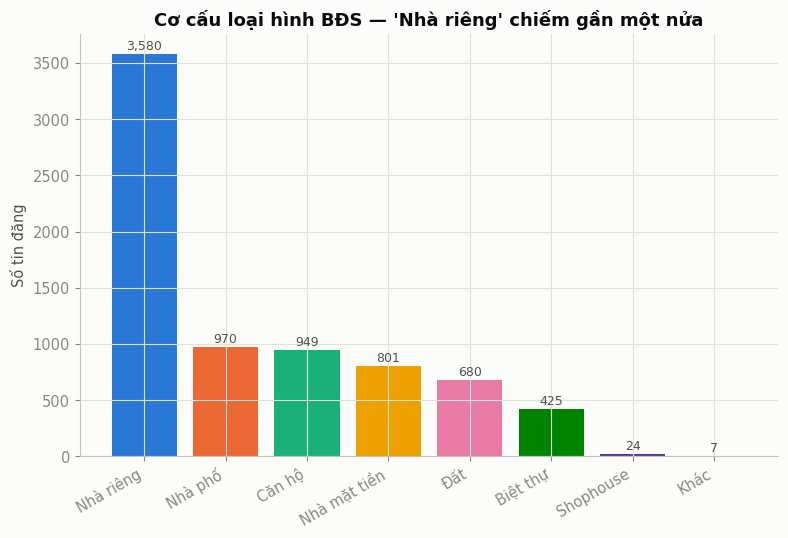

In [ ]:
co_cau = df["loai_hinh"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(co_cau.index, co_cau.values, color=CAT_PALETTE[:len(co_cau)])
ax.set_ylabel("Số tin đăng")
ax.set_title("Cơ cấu loại hình BĐS — 'Nhà riêng' chiếm gần một nửa")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for b, v in zip(bars, co_cau.values):
    ax.text(b.get_x() + b.get_width()/2, v + 40, f"{v:,}", ha="center", fontsize=9, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

**Nhận xét:** `Nhà riêng` chi phối thị trường với 48,1% mẫu (3.580/7.436) trong tập dữ liệu này. Cần cân nhắc gộp nhóm hoặc loại trừ các nhóm hiếm (Shophouse: 24 tin, Khác: 7 tin) khi huấn luyện mô hình để tránh nhiễu do cỡ mẫu quá nhỏ.

### 3.10. Tỷ lệ đặc điểm tiện ích / pháp lý

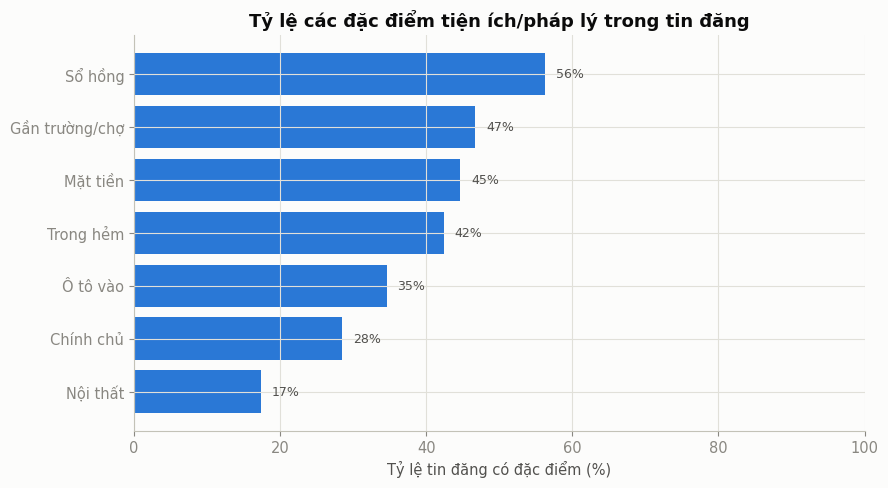

In [ ]:
co_dac_diem = {
    "Mặt tiền": "la_mat_tien", "Trong hẻm": "la_hem", "Sổ hồng": "co_so_hong",
    "Nội thất": "co_noi_that", "Ô tô vào": "oto_vao", "Gần trường/chợ": "gan_truong_cho",
    "Chính chủ": "chinh_chu",
}
ty_le = {ten: df[col].mean() * 100 for ten, col in co_dac_diem.items()}
ty_le = dict(sorted(ty_le.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(list(ty_le.keys()), list(ty_le.values()), color=COLORS["blue"])
ax.set_xlabel("Tỷ lệ tin đăng có đặc điểm (%)")
ax.set_xlim(0, 100)
ax.set_title("Tỷ lệ các đặc điểm tiện ích/pháp lý trong tin đăng")
for b, v in zip(bars, ty_le.values()):
    ax.text(v + 1.5, b.get_y() + b.get_height()/2, f"{v:.0f}%", va="center", fontsize=9, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

**Nhận xét:** Sổ hồng là đặc điểm phổ biến nhất (56% tin đăng), tiếp theo là gần trường/chợ (47%) và mặt tiền (45%); nội thất hiếm nhất (17%). Đáng chú ý: chỉ 28% tin đăng ghi "chính chủ" nghĩa là phần lớn (72%) có khả năng qua môi giới/trung gian, một yếu tố có thể ảnh hưởng giá niêm yết nhưng chưa được đưa vào phân tích. Cần nhắc lại: đây là cờ tự khai báo bởi người đăng tin, không được xác minh độc lập, nên 56% "có sổ hồng" là tỷ lệ được công khai trong tin đăng, không hẳn là tỷ lệ thực của thị trường.

## 4. Kết luận tổng hợp

### Tóm tắt phát hiện chính
- **Giá bán** lệch phải mạnh (skewness 1,76→0,09 sau log) — dùng `log_gia_ban` làm biến mục tiêu; giữ nguyên giá trị cao (max 44 tỷ), không cắt outlier, vì sau log không còn là điểm cực đoan tách biệt.
- **Diện tích** (r=0,57) và mật độ xây (r=0,54) là hai biến số dự báo mạnh nhất.
- **Loại hình bất động sản** tạo chênh lệch giá rất lớn (Căn hộ rẻ nhất, Biệt thự/nhà mặt tiền đắt nhất) — bắt buộc phải là biến hạng one-hot.
- **Vị trí (quận/huyện)** ảnh hưởng giá rõ (Quận 1 gấp ~1,9 lần TP. Thủ Đức); Quận 7 là phát hiện đáng chú ý vì giá gần ngang Quận 1 dù không phải quận trung tâm truyền thống.
- Số phòng ngủ–số WC (r=0,73) và số tầng–mật độ xây (r=0,70) là hai cặp đa cộng tuyến thực sự đáng lo ngại, không phải "nhẹ" — cần Ridge hoặc loại bớt biến khi hồi quy tuyến tính.
- Diện tích–số tầng gần như độc lập (r=-0,03), một phát hiện phản trực giác đáng ghi nhận.
- Dữ liệu mất cân bằng theo loại hình và quận/huyện — cần ngưỡng cỡ mẫu tối thiểu nhất quán trước khi one-hot.
- `quan_huyen` có 20 nhóm phân bố lệch mạnh → Random Forest chịu đựng tốt hơn Linear Regression khi one-hot tạo nhiều cột tần suất thấp, củng cố lý do ưu tiên bộ ba Linear → Tree → Forest.

### Lựa chọn mô hình cho bước huấn luyện tiếp theo

| Mô hình | Lý do chọn |
|---|---|
| **Hồi quy tuyến tính** | Baseline diễn giải được; quan hệ log(diện tích)–log(giá) gần tuyến tính nên phù hợp làm mức sàn so sánh |
| **Cây quyết định** | Nắm bắt ranh giới giá không tuyến tính giữa các loại hình/quận (ngưỡng, không phải dốc đều) |
| **Rừng ngẫu nhiên** | Khắc phục overfit của cây đơn, thường cho R² cao nhất với dữ liệu dạng bảng cỡ vừa; cho biết mức độ quan trọng của từng đặc trưng |

Bộ ba **Linear → Tree → Forest** đã được triển khai sẵn tại `src/models/huan_luyen_mo_hinh.py`, đánh giá bằng R², RMSE, MAE và kiểm định chéo (cross-validation).
